# Informe inicial

___
- Oscar Josue Rocha Hernandez
- Rafael Takata Garcia
- Esteban Gomez Valerio

### Introducción
El análisis que se presenta se ubica en el ámbito de los estudios socioeconómicos y laborales en Estados Unidos, un tema de gran relevancia para comprender la distribución de ingresos y las dinámicas del mercado de trabajo. Este tipo de análisis no solo tiene implicaciones académicas, sino también aplicaciones prácticas en el diseño de políticas públicas, estrategias empresariales y estudios de equidad social.

El problema que abordaremos es la evaluación de los factores que influyen en el nivel de ingresos de las personas. En particular, se busca identificar cómo variables como la edad, la educación, el estado civil, la ocupación, el sexo y la raza están asociadas con la probabilidad de que un individuo perciba ingresos superiores a los 50 mil dólares anuales. Entender estas relaciones es esencial para detectar patrones de desigualdad y áreas de oportunidad en el desarrollo económico.

El alcance de esta primera entrega se centrará en la exploración inicial del conjunto de datos. No se incluirán modelos predictivos avanzados, sino un estudio descriptivo que permita conocer la estructura del dataset, explorar la distribución de las variables y visualizar tendencias generales entre las características sociodemográficas y el nivel de ingresos.

Para este propósito, se utilizará el dataset de Adult Census Income, que contiene información de miles de individuos en Estados Unidos. Cada registro incluye variables como educación, ocupación, horas trabajadas, país de origen y otros atributos, junto con la etiqueta de ingresos (<=50K o >50K). Este dataset ha sido ampliamente utilizado como benchmark en problemas de clasificación en aprendizaje automático, lo que lo convierte en un recurso ideal para este análisis exploratorio.
___

### Antecedentes

Este dataset fue creado y popularizado a partir de trabajos en aprendizaje automático que buscaban clasificar ingresos, a menudo sirviendo como un punto de referencia para nuevos algoritmos.

`Kohavi, R. (1996). Scaling up the accuracy of naive-Bayes classifiers: A decision-tree approach. In E. Simoudis, J. Han, & U. Fayyad (Eds.), Proceedings of the Second International Conference on Knowledge Discovery and Data Mining (KDD-96) (pp. 202–207). AAAI Press.`

- Este es uno de los primeros trabajos que utiliza el dataset para probar métodos de clasificación (Naive Bayes y árboles de decisión), estableciendo un benchmark inicial en términos de precisión.

`Dua, D., & Graff, C. (2017). UCI Machine Learning Repository. Irvine, CA: University of California, School of Information and Computer Science. Retrieved from http://archive.ics.uci.edu/ml`

- Aunque este es el propio repositorio de los datos, estudiantes generalmente se centran en el preprocesamiento de datos y la ingeniería de características con el fin de impactar en el rendimiento predictivo.


Mediante estos trabajos previos, se confirma que las variables como la educación, ocupación y la edad, son altamente predictivas del nivel de ingresos. Esto valida su enfoque inicial de análisis exploratorio para comprender las relaciones de estas variables con la variable a predecir (ingresos).

La mayoría de los benchmarks en machine learning se enfocan en medir la precisión predictiva de los modelos, pero dejan en segundo plano la explicación de los patrones entre variables. Nuestro proyecto busca cubrir esa brecha, priorizando no solo la exactitud de las predicciones, sino también la comprensión de las relaciones e interacciones entre atributos, con el fin de aportar un valor interpretativo adicional y generar conocimiento útil a futuro.
___


### Objetivos
*Desarrollar un sistema reproducible de predicción de ingresos basado en el dataset Adult Income, que integre un pipeline de procesamiento, entrenamiento y evaluación de modelos, garantizando un rendimiento robusto y trazable mediante MLflow.*

**Objetivos especificos**

- Construir un pipeline reproducible que incluya limpieza, transformación, codificación y vectorización de datos (one-hot/numérico para atributos tabulares).

- Evaluar al menos tres familias de modelos (Gradient Boosting Random Forest, XGBoost), incluyendo búsqueda de hiperparámetros y comparación sistemática en MLflow.

- Implementar un proceso de selección y registro automático de modelos basado en la métrica principal (F1), guardando artefactos, métricas y parámetros.

- Diseñar y documentar una API que permita consumir el modelo final y exponer predicciones en un entorno realista, crear un Docker container con las dependencias de dicho modelo y subirlo a Hugging Face.

- Generar reportes y visualizaciones que describan las variables del dataset, su relación con la variable objetivo y el desempeño de los modelos entrenados.
___

**Criterios de exito**

Métrica principal: Accuracy.

- Accuracy ≥ 0.75

Registro automático correcto para los modelos 
___

**Riesgos Asociados**

Disponibilidad y calidad de datos:

- Valores faltantes, categorías raras o ruido en variables como workclass u occupation.

Complejidad y latencia de modelos:

- Árboles complejos (Random Forest / XGBoost) pueden incrementar el tiempo de inferencia y el costo computacional.

Reproducibilidad y trazabilidad:

- Configuraciones inconsistentes en MLflow o versiones de librerías pueden afectar la reproducibilidad de los experimentos.


### Planteamiento del problema

**Formulación Precisa**

El problema es construir un modelo de clasificación binaria para predecir, con alta precisión e interpretabilidad, si el ingreso anual es $>\$50K$ o $\le\$50K$, basándose en características sociodemográficas.

**Variables Clave**

Las entradas (features) son las características sociodemográficas y económicas (age, workclass, education, occupation, etc.), la salida (target) es la variable binaria income ($\le\$50K$ o $>\$50K$).

**Restricciones**

Las restricciones principales son el desbalance y la calidad del conjunto de datos, la necesidad de que funcione de manera correcta en nuestra API (FastAPI/Streamlit).

**Impacto Esperado**

La solución permite a las empresas identificar proactivamente clientes de alto valor (ingresos $>\$50K$), lo que optimiza las estrategias de marketing y la asignación de recursos.

**Riesgos**

Los principales riesgos son el desbalance de clases y los sesgos en variables sensibles. También se debe gestionar el riesgo de valores faltantes/ruido mediante limpieza exhaustiva y evitar el sobreajuste (overfitting).
___

### Analisis exploratorio

La exploración se centró en entender las variables numéricas y categóricas, sus distribuciones y relaciones, así como en identificar patrones relevantes por género y ocupación.

**Hallazgos principales**

Las variables presentan diferentes patrones de distribución: la edad sigue una forma casi normal con la mayoría entre 25 y 45 años; el peso final muestra un fuerte sesgo positivo con la mayoría de los valores bajos; el nivel educativo numérico es multimodal, destacando los niveles medio y universitario; tanto la ganancia como la pérdida de capital están altamente sesgadas a la derecha con la mayoría de los valores en cero; y las horas trabajadas por semana se concentran en 40, con algunos casos que superan las 50 o 60 horas.

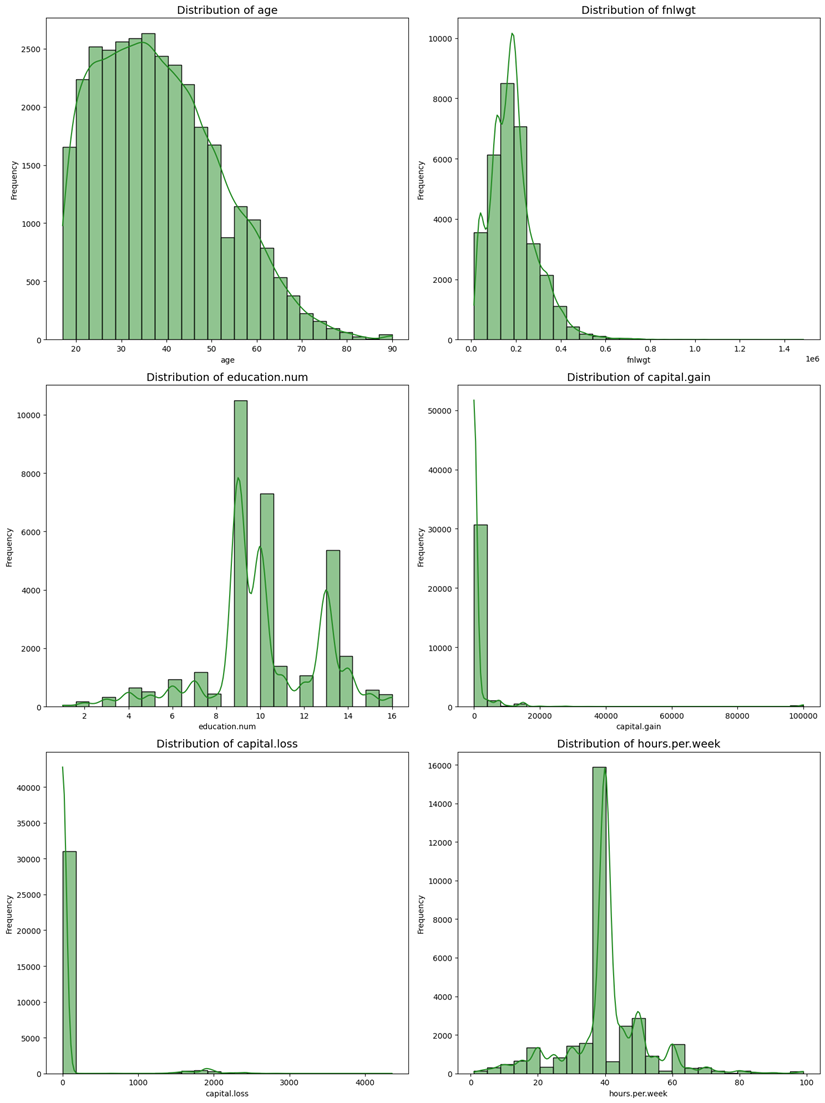

La matriz de correlación a continuación muestra que las variables numéricas son en su mayoría independientes, con valores cercanos a cero y sin relaciones lineales fuertes. Las correlaciones más notables, aunque débiles, se dan entre el nivel educativo y las horas trabajadas (0.15), así como entre el nivel educativo y la ganancia de capital (0.12). En general, la baja correlación entre variables es positiva para la creación de modelos predictivos, ya que disminuye el riesgo de multicolinealidad.`

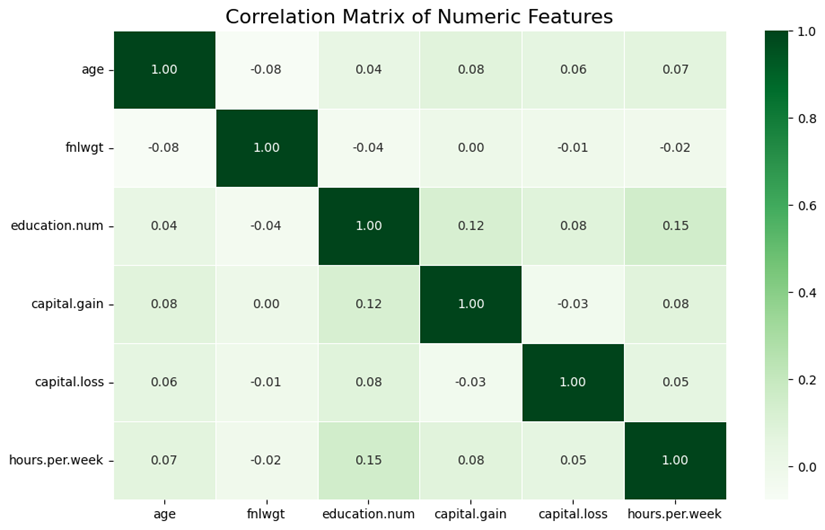

*Mas visualizaciones en `notebooks/01_eda_inicial.ipynb`*
____
**Posibles Riesgos**

- Los outliers en capital gain/loss requieren un tratamiento especial, pueden crear sesgo en nuestros modelos.

- Se detectan sesgos de género y ocupación (entre clases), lo que implica que el modelo predictivo podría reproducir estas desigualdades; será necesario evaluar métricas de equidad.

- La fuerte correlación entre 'education' y 'education.num' sugiere eliminar una de ellas para evitar multicolinealidad.

- La codificación de variables categóricas con muchas categorías (como native.country o occupation) debe manejarse cuidadosamente para evitar un alto número de dimensiones.
___

### Data Wrangling

El proceso de Data Wrangling en *`notebooks/02_data_wrangling.ipynb`* se enfocó en la preparación del dataset `adult.csv` para el modelado.

El proceso de Data Wrangling en el código utiliza el objeto `ColumnTransformer` de `scikit-learn` para aplicar dos técnicas principales de transformación:

- Estandarización (`StandardScaler`) para las columnas numéricas.

- One-Hot Encoding (`OneHotEncoder`) para las columnas categóricas.

Ademas la columna income se convierte en una variable binaria (0 o 1).

- `1` si el ingreso es `>50K`

- `0` si el ingreso es`<=50K`

Se eliminan la variable objetivo (income) y la columna education.

- *Education se elimina porque se considera redundante con la columna education.num*

Los datos se dividen en tres conjuntos: Entrenamiento (70%), Validación (15%) y Prueba (15%).

- *La división es estratificada, lo que asegura que la proporción de la variable objetivo (income) sea la misma en los tres conjuntos.*

A continuacion se muestra un ejemplo del antes y el despues del preprocesamiento, el cual se encuentra actualmente en la ruta de `data/processed/pre_processed_data.csv`

**ANTES**
___
![Screenshot 2025-12-02 143050.png](<attachment:Screenshot 2025-12-02 143050.png>)
___
**DESPUES**
___

![Screenshot 2025-12-02 143027.png](<attachment:Screenshot 2025-12-02 143027.png>)


___
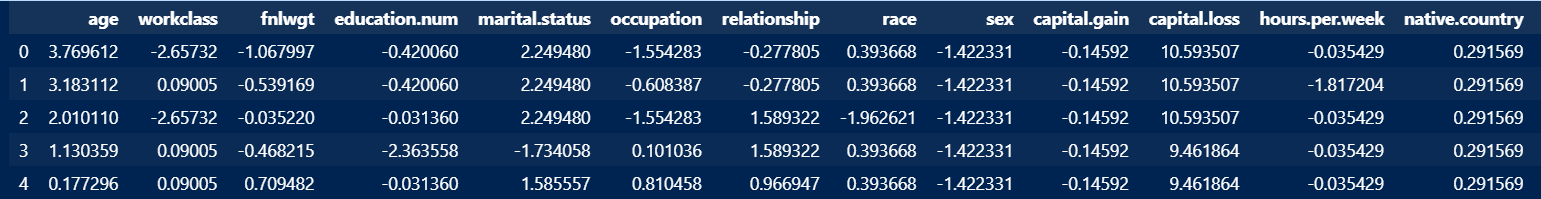
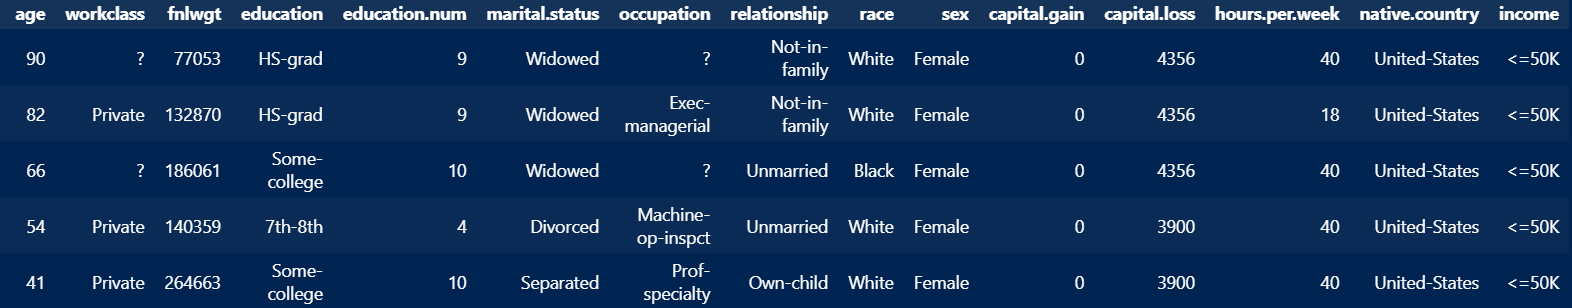

### Entrenamiento del modelo con MLflow

El proyecto se centró en el` entrenamiento y optimización de tres modelos de clasificación para la predicción de ingresos: 
- `Random Forest Classifier`
- `Gradient Boosting Classifiery `
- `XGBoost Classifier`

La metodología se basó en una partición de datos en conjuntos de entrenamiento, validación y prueba para asegurar una evaluación robusta.

La optimización de hiperparámetros (HPO) se realizó utilizando la librería Optuna, cuyo objetivo fue minimizar la expresión $\$1 - F1\_score\$$ sobre el conjunto de validación, buscando así maximizar el $F1\_score$ del clasificador. 

Todo el proceso se gestionó con MLflow, registrando los parámetros de cada prueba, las métricas clave ($F1\_score$, precisión y recall), y el modelo final. 

El mejor rendimiento se obtuvo con el modelo XGBoost Classifier, que alcanzó un $F1\_score$ de aproximadamente $0.7077$ en el conjunto de prueba.

Finalmente, los artifacts cruciales, como el modelo serializado y el objeto preprocesador, fueron guardados en MLflow para el despliegue.
___
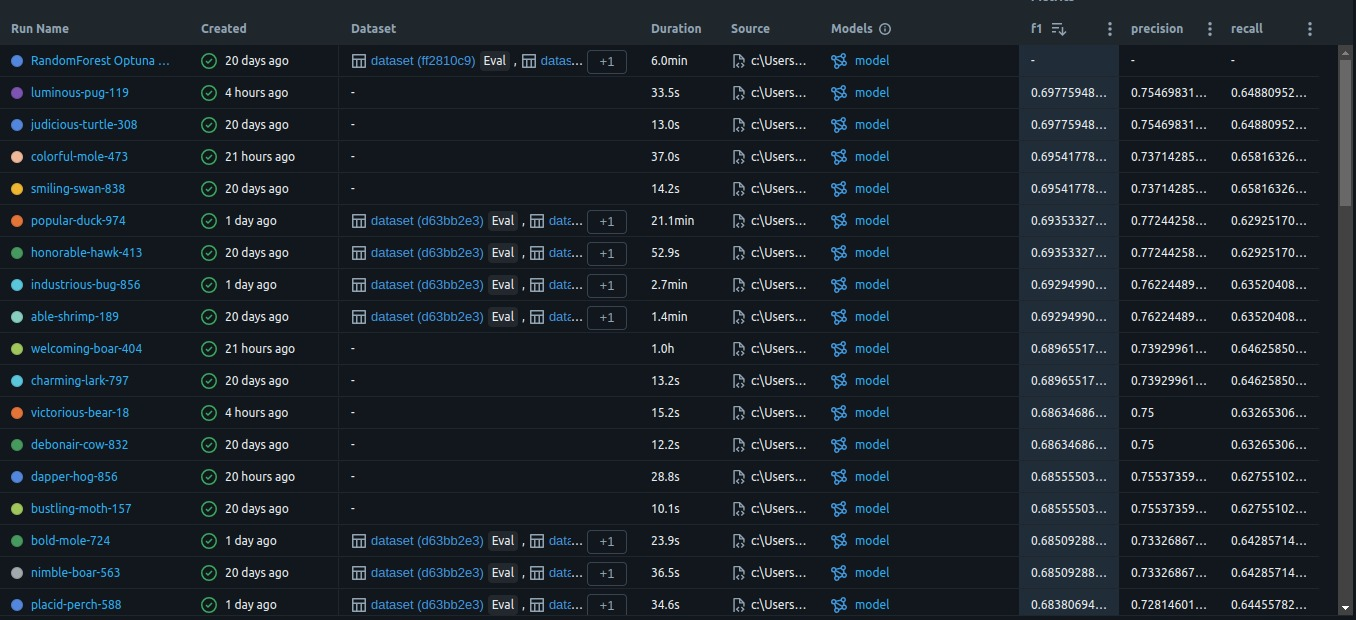
___
Nuestro modelo registrado como `"Champion"` fue un **XGBoost classifier** con parametros de Optuna.

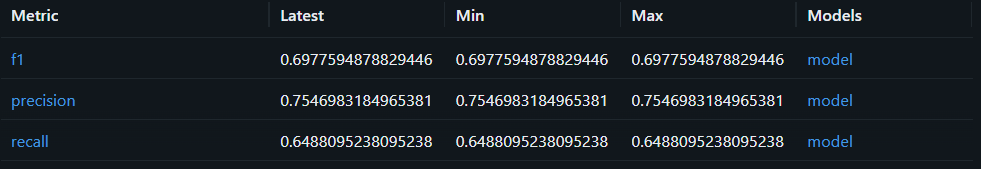
___

### Mejor modelo
El criterio objetivo principal utilizado en la optimización de hiperparámetros (HPO) con Optuna fue maximizar el $F1\_score$. La métrica $F1$ fue la métrica de referencia para seleccionar el mejor modelo candidato.
___

**Parametros**

- `colsample_bytree`: 0.9474136752138245

- `gamma`: 2.9894998940554256

- `learning_rate`: 0.13962563737015762

- `max_depth`: 12

- `n_estimators`: 155

- `random_state`: 42

- `reg_lambda`: 4.869640941520899

- `subsample`: 0.9697494707820946
___

**Justificacion**

`Rendimiento`: El XGBoost ofreció el mejor $F1\_score$ en el conjunto de prueba, alcanzando aproximadamente $0.7077$. Esto supera a modelos como Random Forest, que demostró métricas de $F1$ y recall inferiores en validación.

`Rendimiento vs. Costo`: Aunque el XGBoost es más complejo que otros modelos de árbol, su incremento de rendimiento compensa el ligero aumento de latencia o costo computacional en producción.

`Conclusión`: Debido a que el objetivo principal es lograr la mejor predicción de ingresos, el *XGBoost Classifier* es la elección óptima.
___
El mejor modelo es:
- `Nombre del Modelo`: income-prediction-classifier

- `Versión del Modelo`: Versión 3

- `Alias Asignado`: @champion.

- `Artifacts Registrados`: MLmodel, conda.yaml, model.pkl e input_example.json

___


### Training Pipeline

El flujo automatizado funciona coordinando las tareas clave de un proyecto de Machine Learning utilizando Prefect como orquestador principal y MLflow para la gestión de experimentos y modelos.

El proceso inicia con la tarea Load and Preprocess Data, que lee el archivo de datos, lo limpia, separa la variable objetivo (income) y lo divide en conjuntos de entrenamiento, validación y prueba (raw y preprocesados). Esta tarea también entrena y serializa el objeto ColumnTransformer (preprocesador) necesario para transformar futuros datos de entrada.

Una vez que los datos están listos, el flujo ejecuta en paralelo tres tareas Tune Model Family, una para cada familia de modelos (**Random Forest**, **Gradient Boosting**, y **XGBoost**). Cada una utiliza Optuna para la Optimización de Hiperparámetros (HPO), buscando maximizar el $F1\_score$ en el conjunto de validación, y registra cada intento (trial) como un run anidado en MLflow.

Tras la HPO, el flujo procede con tres tareas Train Final Challenger, también en paralelo, para construir el modelo final de cada familia. Esta tarea es crucial porque crea un Pipeline completo de Scikit-learn que encapsula el preprocesador y el modelo entrenado con los mejores hiperparámetros. Este pipeline completo se registra en MLflow junto con sus métricas y la firma, listo para la inferencia con datos raw.

Finalmente, la tarea Compare and Promote Champion consulta los resultados en MLflow, identifica el modelo con el mejor $F1\_score$ y lo promueve en el MLflow Model Registry asignándole el alias `@champion`. El segundo mejor modelo se promueve como `@challenger`.
___
**Diagrama**

    A[Inicio Flujo] --> C(Load and Preprocess Data @task)
    
    subgraph HPO en Paralelo
        C --> D1(Tune Random Forest @task)
        C --> D2(Tune Gradient Boosting @task)
        C --> D3(Tune XGBoost @task)
    end
    
    subgraph Entrenamiento y Registro Challenger
        D1 --> E1(Train Final Challenger RF @task)
        D2 --> E2(Train Final Challenger GB @task)
        D3 --> E3(Train Final Challenger XGB @task)
    end

    E1 & E2 & E3 --> F(Compare and Promote Champion @task)
    F --> G[Fin Pipeline]

___

### Correr Pipeline

El comando para ejecutar el pipeline se introduce de la siguiente manera:

``` bash
    python /src/pipelines/train_pipeline.py
```
___

### Manejo de errores
- **Logs**: Los logs se gestionan automáticamente por Prefect, proporcionando una vista centralizada del estado y la actividad de cada @task y del flujo completo. Además, durante la HPO y el registro, MLflow captura logs detallados de los parámetros y métricas para cada modelo probado.

- **Manejo de Fallos**: El código incluye un manejo de excepciones explícito en la tarea tune_model_family para evitar que pequeños errores durante el logging de un modelo candidato detengan la costosa optimización completa de Optuna.
___

### API con FastAPI

El modelo de predicción de ingresos se sirve a través de una API web desarrollada con FastAPI. El objetivo principal de este servicio es proporcionar predicciones de ingresos.

1. Carga del Modelo
El servicio utiliza **MLflow** para cargar el modelo directamente desde el Model Registry alojado en Databricks.

Modelo Cargado: El pipeline completo (que incluye el preprocesador `ColumnTransformer` y el modelo final) se carga usando la URI `models:/workspace.default.income-prediction-classifier-prefect@champion`.

Artifacts Clave: El modelo cargado es un pipeline completo, como lo demuestra el archivo `model.pkl`registrado en la versión 3 del modelo.
___

2. Endpoints Mínimos
La API expone dos endpoints fundamentales para la monitorización y la inferencia:

- **health**: `metodo --> "GET"` verificar que el servicio está activo y respondiendo.

- **predict**: `metodo --> "POST"` Recibe los datos de entrada (features) en formato JSON y devuelve la predicción de ingresos (cuyo valor binario es 0 ó 1, y la clase asociada).
___

3. Flujo Interno y Preprocesamiento Consistente

El flujo de inferencia garantiza que los datos de entrada sean tratados de manera idéntica a como se hizo durante el entrenamiento:

- **Validación de Input (Pydantic)**: La estructura del JSON de entrada se valida mediante la clase IncomeRequest de Pydantic, lo que asegura que todos los campos y tipos de datos esperados estén presentes.

- **Preprocesamiento Consistente**: La función predict_endpoint recibe el JSON, lo convierte en un DataFrame de Pandas, y renombra las columnas para que coincidan exactamente con los nombres esperados durante el entrenamiento.

4. Manejo de Errores y Respuesta
El servicio utiliza códigos HTTP estándar y mensajes claros para la comunicación.

- **Códigos HTTP**: Se espera un 200 OK para una predicción exitosa.

- **Mensajes Claros**: La respuesta JSON de éxito incluye tanto el valor binario (prediction: 1 ó 0) como una interpretación humana (class: >50K ó <=50K).
___
### App
- **Numéricos**: Se usan campos de entrada numérica (st.sidebar.number_input) para variables como age, fnlwgt, capital_gain, etc.

- **Categóricos**: Se emplean menús desplegables (st.sidebar.selectbox) con opciones predefinidas (ej. Workclass, Education, Occupation, etc.) que reflejan los valores del conjunto de datos de entrenamiento.
___
### Ejecutar App y API

El comando para ejecutar la API se ejecuta de la siguiente manera desde la carpeta `src/backend`:

``` bash
    uvicorn api:app --reload
```

El comando para ejecutar la app se ejecuta de la siguiente manera desde la carpeta `src/frontend`:

``` bash
    streamlit run app.py
```
___

### Ejemplo de uso
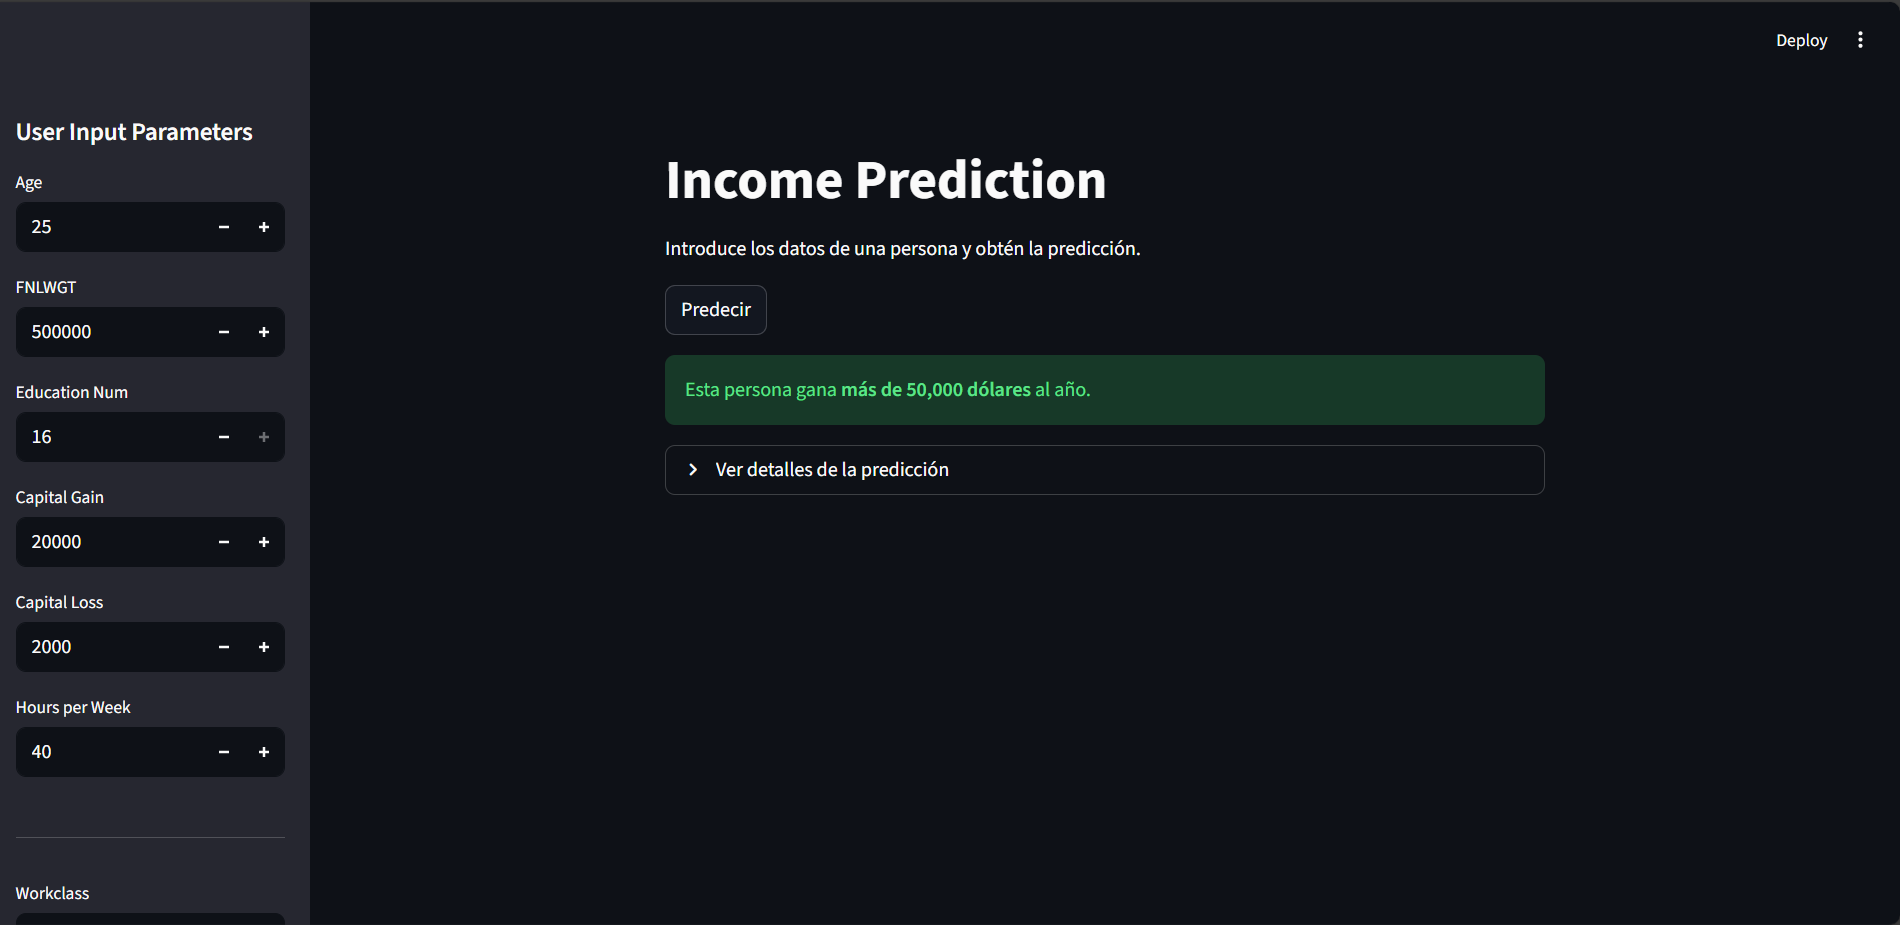
___

### Docker

**Dockerfile backend**

``` Dockerfile
    FROM python:3.13-slim

    WORKDIR /code

    COPY ./requirements.txt /code/requirements.txt

    RUN apt-get update && apt-get install -y procps && \
        pip install -U pip && \
        rm /etc/localtime && \
        ln -s /usr/share/zoneinfo/America/Mexico_City /etc/localtime && \
        pip install -r ./requirements.txt

    COPY ./api.py /code/

    EXPOSE 8000

    CMD ["uvicorn","api:sapp", "--host", "0.0.0.0", "--port", "8000"]
```
___
**Dockerfile frontend**
``` Dockerfile
FROM python:3.13-slim

WORKDIR /code

RUN apt-get update && apt-get install -y procps && \
    pip install -U pip && \
    rm -rf /var/lib/apt/lists/*

COPY ./requirements.txt /code/requirements.txt

RUN pip install -r ./requirements.txt

COPY ./app.py /code/

EXPOSE 8501

CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0"]
```
___
**Docker-compose.yaml**

``` yaml
name: income-pred-app 

services:
  ui:
    image: income-pred-ui-image:latest                
    container_name: income-pred-ui-container
    build:
      context: ./src/frontend  
      dockerfile: Dockerfile
    ports:
      - "8501:8501"
    network_mode: host
    command: streamlit run app.py --server.port=8501 --server.address=0.0.0.0

  api:
    image: income-pred-api-image:latest
    container_name: income-pred-api-container
    build:
      context: ./src/backend
      dockerfile: Dockerfile
    ports:
      - "8000:8000"
    env_file:
      - ./.env
    network_mode: host
    command: uvicorn api:app --host 0.0.0.0 --port 8000
```
___

La configuración de Docker establece dos servicios ligeros, backend y frontend, utilizando la imagen base python:3.13-slim para optimizar el tamaño de las imágenes. El backend contiene la API de FastAPI que aloja el modelo, expuesta en el puerto 8000 y utiliza un archivo **.env** para cargar de forma segura las credenciales de MLflow/Databricks necesarias para cargar el modelo `@champion`. El frontend contiene la aplicación Streamlit para la interfaz de usuario, expuesta en el puerto 8501. Ambos servicios usan network_mode: host en **docker-compose.yaml** para simplificar la conexión en la máquina local.

La orquestación con Docker Compose permite construir y lanzar ambos servicios simultáneamente. Aunque la configuración es robusta, se identifican áreas de mejora, como la corrección de sintaxis del comando **uvicorn** en el Dockerfile del backend (`api:sapp debería ser api:app`) y la necesidad de una dependencia explícita (depends_on) del servicio ui al servicio api para asegurar que el backend esté listo antes de que el frontend intente llamarlo.
___



### Despliegue en HuggingFace


### Conclusiones

En esta fase se logró preparar el dataset Adult Census Income para la etapa de modelado. Se transformaron las variables categóricas a formato numérico, se descartaron redundancias como education frente a education.num, y se estandarizaron las variables numéricas para asegurar comparabilidad. Además, se aplicó un filtro de correlación para conservar solo aquellas variables con mayor aporte predictivo, quedando un conjunto de datos más limpio y manejable.

1. Aún no se han definido pruebas estadísticas adicionales ni técnicas de reducción de dimensionalidad.

2. El dataset todavía no ha sido particionado en entrenamiento, validación y prueba.

3. Falta generar variables derivadas que capten interacciones más complejas.

4. No se han definido métricas de evaluación ni un modelo baseline.
___

#### Roadmap inmediato

**Feature Engineering**


Crear nuevas variables derivadas (ej. rangos de edad, combinaciones de educación y ocupación).

**Particiones de los datos**


Separar en entrenamiento, validación y prueba con muestreo estratificado.

**Métricas objetivo**


Seleccionar métricas adecuadas para clasificación binaria (accuracy, F1, ROC-AUC).

**Baselines**


Implementar modelos iniciales como regresión logística y árboles de decisión básicos.
Comparar contra una predicción ingenua (ej. siempre “<=50K”) para medir la ganancia real.

### Referencias

- https://www.kaggle.com/datasets/mosapabdelghany/adult-income-prediction-dataset

- Kohavi, R. (1996). Scaling up the accuracy of naive-Bayes classifiers: A decision-tree approach. In E. Simoudis, J. Han, & U. Fayyad (Eds.), Proceedings of the Second International Conference on Knowledge Discovery and Data Mining (KDD-96) (pp. 202–207). AAAI Press.